In [1]:
print("Logistics Data Analyst Internship")
print("Delivery Performance Analysis")

Logistics Data Analyst Internship
Delivery Performance Analysis


In [2]:
import pandas as pd

orders = pd.read_csv("/content/olist_orders_dataset.csv")

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
print("Number of rows:", orders.shape[0])
print("Number of columns:", orders.shape[1])

Number of rows: 99441
Number of columns: 8


In [4]:
print(orders.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')


In [5]:
date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

print(orders[["order_id", "delivery_days"]].head())

                           order_id  delivery_days
0  e481f51cbdc54678b7cc49136f2d6af7            8.0
1  53cdb2fc8bc7dce0b6741e2150273451           13.0
2  47770eb9100c2d0c44946d9cf07ec65d            9.0
3  949d5b44dbf5de918fe9c16f97b45f8a           13.0
4  ad21c59c0840e6cb83a9ceb5573f8159            2.0


In [6]:
orders["is_late"] = (
    orders["order_delivered_customer_date"]
    > orders["order_estimated_delivery_date"]
).astype(int)

print(orders[["order_id", "is_late"]].head())

                           order_id  is_late
0  e481f51cbdc54678b7cc49136f2d6af7        0
1  53cdb2fc8bc7dce0b6741e2150273451        0
2  47770eb9100c2d0c44946d9cf07ec65d        0
3  949d5b44dbf5de918fe9c16f97b45f8a        0
4  ad21c59c0840e6cb83a9ceb5573f8159        0


In [7]:
late_delivery_rate = orders["is_late"].mean() * 100

print("Late Delivery Rate:", round(late_delivery_rate, 2), "%")

Late Delivery Rate: 7.87 %


In [8]:
average_delivery_time = orders["delivery_days"].mean()

print(
    "Average Delivery Time:",
    round(average_delivery_time, 2),
    "days"
)

Average Delivery Time: 12.09 days


In [9]:
total_orders = len(orders)

late_orders = orders["is_late"].sum()

on_time_orders = total_orders - late_orders

print("Total Orders:", total_orders)
print("Late Orders:", late_orders)
print("On-Time Orders:", on_time_orders)

Total Orders: 99441
Late Orders: 7827
On-Time Orders: 91614


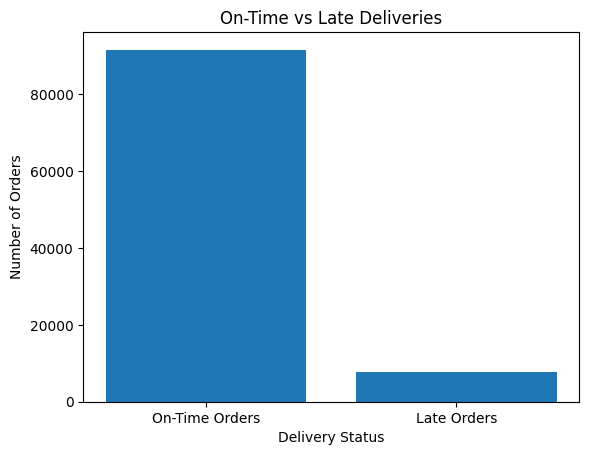

In [10]:
import matplotlib.pyplot as plt

labels = ["On-Time Orders", "Late Orders"]
values = [on_time_orders, late_orders]

plt.bar(labels, values)

plt.title("On-Time vs Late Deliveries")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.show()